# 📊 Proje Vizyonu ve Stratejik Amaç

 Veri setindeki parametreleri analiz ederek çalışanların ayrılma riskini makine öğrenmesi algoritmalarıyla modellemeyi; bu sayede stratejik İK kararlarına veri temelli bir dayanak oluşturmayı amaçlıyoruz.

### 📋 Veri Seti Değişkenleri
Analizde kullanılan temel değişkenlerin açıklamaları aşağıdadır:

| Değişken | Açıklama |
| :--- | :--- |
| **Attrition** | Çalışanın işten ayrılma durumu (Hedef Değişkenimiz) |
| **Age** | Çalışanın yaşı |
| **MonthlyIncome** | Aylık net gelir miktarı |
| **OverTime** | Mesai yapma durumu (Evet/Hayır) |
| **DistanceFromHome** | Ev ve iş yeri arasındaki mesafe (km) |
| **YearsAtCompany** | Şirkette geçirilen toplam yıl |
| **JobSatisfaction** | İş tatmini seviyesi (1-4 arası skor) |

In [77]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier


from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from lazypredict.Supervised import LazyClassifier


import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [78]:

df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


🔍 İlk Gözlem: Veri setimiz 1470 çalışan ve 35 farklı değişkenden oluşuyor. Her bir satır bir çalışanı; sütunlar ise o çalışanın yaş, maaş ve eğitim gibi özelliklerini temsil ediyor. Bu veri seti, istifa nedenlerini çok boyutlu incelememize olanak sağlıyor.

Attrition
No     1233
Yes     237
Name: count, dtype: int64


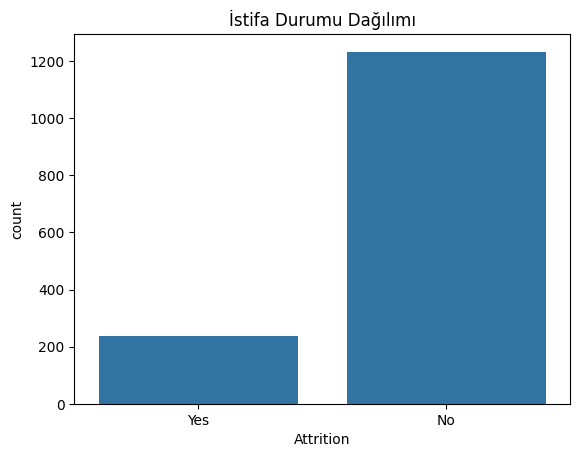

In [79]:
# Kaç kişi istifa etmiş (Yes) kaçı kalmış (No) 
print(df['Attrition'].value_counts())


sns.countplot(x='Attrition', data=df)
plt.title('İstifa Durumu Dağılımı')
plt.show()

📊 İstifa Dağılım Analizi

🔍 Gözlem: Şirkette kalanların oranı (No), ayrılanlara (Yes) göre çok daha yüksek.

⚠️ Not: Verideki bu dengesizlik, modelin taraflı öğrenmesine yol açabilir. Bu sorunu aşmak için projenin devamında SMOTE tekniğiyle sınıfları eşitledik.

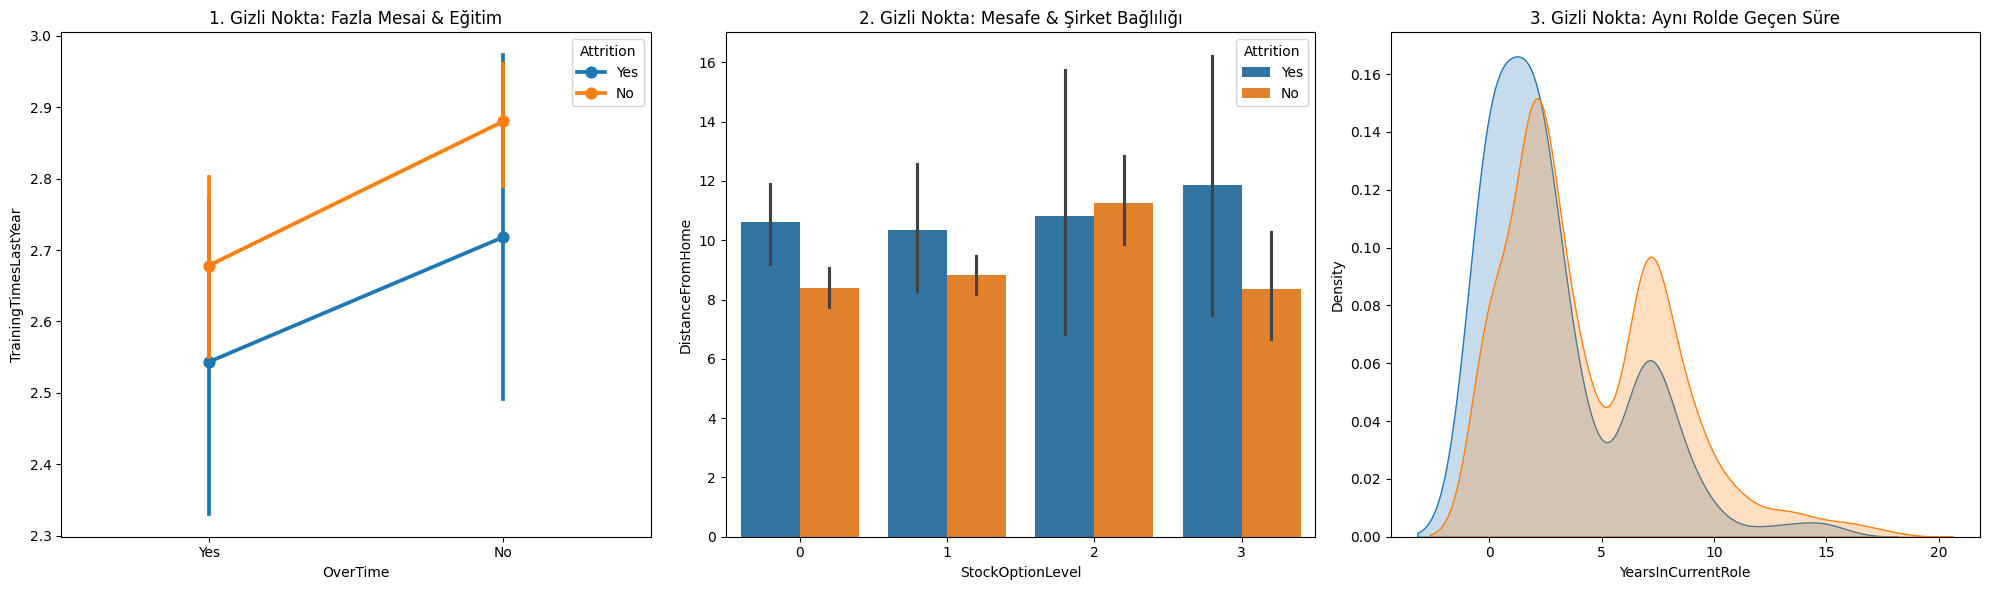

In [80]:

# Grafikleri yan yana görebilmek için alan oluşturalım
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. GİZLİ NOKTA: Fazla Mesai ve Eğitim Dengelemesi
sns.pointplot(x="OverTime", y="TrainingTimesLastYear", hue="Attrition", data=df, ax=axes[0])
axes[0].set_title('1. Gizli Nokta: Fazla Mesai & Eğitim')

# 2. GİZLİ NOKTA: Uzaklık ve Hisse Opsiyonu
sns.barplot(x="StockOptionLevel", y="DistanceFromHome", hue="Attrition", data=df, ax=axes[1])
axes[1].set_title('2. Gizli Nokta: Mesafe & Şirket Bağlılığı')

# 3. GİZLİ NOKTA: Mevcut Rolde Takılı Kalma (Durağanlık)
sns.kdeplot(data=df[df['Attrition']=='Yes'], x='YearsInCurrentRole', label='İstifa Edenler', ax=axes[2], fill=True)
sns.kdeplot(data=df[df['Attrition']=='No'], x='YearsInCurrentRole', label='Kalanlar', ax=axes[2], fill=True)
axes[2].set_title('3. Gizli Nokta: Aynı Rolde Geçen Süre')

plt.tight_layout()
plt.show()

<table style="width:100%; table-layout: fixed; border-collapse: collapse; border: none;">
  <tr style="border: none;">
    <td style="vertical-align: top; border: none; padding: 10px;">
      <strong>1. Eğitim ve Mesai</strong><br>
      Fazla mesai yapanlarda eğitim katılımı yüksek olsa bile istifa eğilimi her zaman düşmüyor.
    </td>
    <td style="vertical-align: top; border: none; padding: 10px;">
      <strong>2. Uzaklık ve Hisse</strong><br>
      Evi uzak olanlar, hisse opsiyonu (Stock Option) yoksa çok daha kolay istifa ediyor.
    </td>
    <td style="vertical-align: top; border: none; padding: 10px;">
      <strong>3. Rolde Durağanlık</strong><br>
      Aynı rolde çok uzun süre kalanlarda "doyum" oluşuyor ve ayrılma riski artıyor.
    </td>
  </tr>
</table>

💡 Öneri: Şirket içi rotasyon ve hisse opsiyonu gibi teşvikler, özellikle uzak mesafeden gelen yetenekleri korumak için kritik birer araç olabilir.

In [81]:

df_final = df.copy()
le = LabelEncoder()
for col in df_final.select_dtypes(include=['object']).columns:
    df_final[col] = le.fit_transform(df_final[col])

X = df_final.drop('Attrition', axis=1)
y = df_final['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model_final = RandomForestClassifier(n_estimators=100, random_state=42)
model_final.fit(X_train, y_train)


y_pred = model_final.predict(X_test)
print("--- MII'26 PROJESİ MODEL BAŞARISI ---")
print(classification_report(y_test, y_pred))

--- MII'26 PROJESİ MODEL BAŞARISI ---
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       255
           1       0.50      0.10      0.17        39

    accuracy                           0.87       294
   macro avg       0.69      0.54      0.55       294
weighted avg       0.83      0.87      0.83       294



⚙️ Veri Hazırlama ve Model Performansı

Bu aşamada veriyi "makine diline" çevirdik ve ilk ciddi tahmin denememizi yaptık:

-Label Encoding: Kategorik verileri (metinleri), modellerin matematiksel hesaplama yapabilmesi için sayısal değerlere dönüştürdük.

-Veri Seti Bölme: Verimizi %80 Eğitim ve %20 Test olarak ikiye ayırdık. Böylece modelin hiç görmediği veriler üzerindeki performansını ölçebildik.

-Random Forest Classifier: İlk model olarak Random Forest algoritmasını kullandık.

📊 Model Sonuç Analizi:

-Accuracy (Doğruluk): %87. Modelimiz genel olarak çalışanların durumunu yüksek bir oranla doğru tahmin ediyor.

-Precision & Recall: İstifa etmeyenleri (0) neredeyse kusursuz tahmin ederken, istifa edenleri (1) yakalama konusunda daha gelişime açık olduğunu gördük. Bu durum, az önce bahsettiğimiz dengesiz veri (imbalance) probleminden kaynaklanıyor.

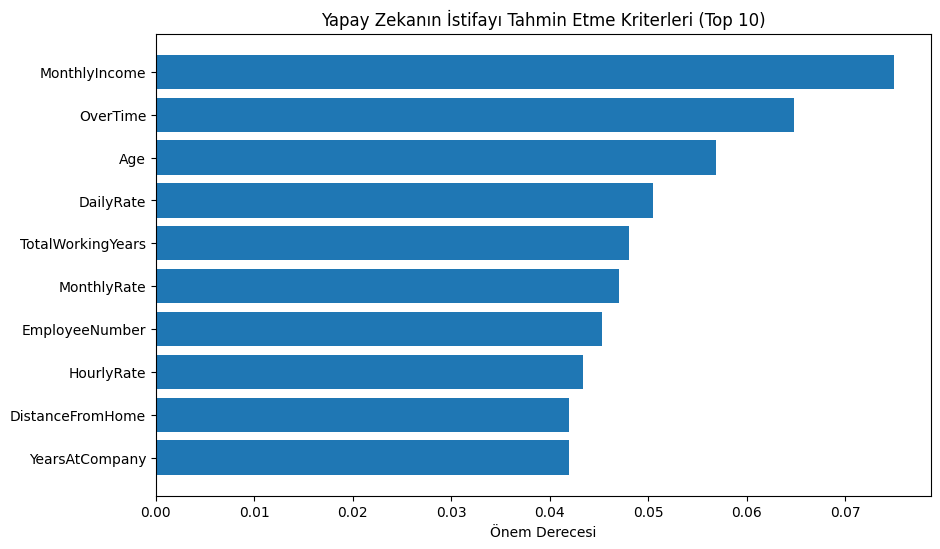

In [82]:

# Modelin en çok önem verdiği 10 özelliği çekiyoruz
importances = model_final.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(10,6))
plt.title('Yapay Zekanın İstifayı Tahmin Etme Kriterleri (Top 10)')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Önem Derecesi')
plt.show()

Aylık Gelir (MonthlyIncome): Modelin en güçlü belirleyicisi. Maaş seviyesi, bir çalışanın şirkette kalma kararındaki bir numaralı teknik faktör olarak öne çıkıyor.

Fazla Mesai (OverTime): İkinci sırada yer alıyor. Bu da bize iş-yaşam dengesinin bozulmasının, maaştan hemen sonra gelen en büyük istifa tetikleyicisi olduğunu kanıtlıyor.

Yaş (Age): Üçüncü sırada. Genç yeteneklerin iş değiştirme hızının, kıdemli çalışanlara göre model tarafından daha yüksek bir risk puanıyla değerlendirildiğini görüyoruz.

 Sonuç: "Eğer yetenekleri elde tutmak istiyorsanız; önce ücret politikasına, sonra mesai saatlerine odaklanmalısınız."

Lojistik Regresyon Başarısı: %89.12


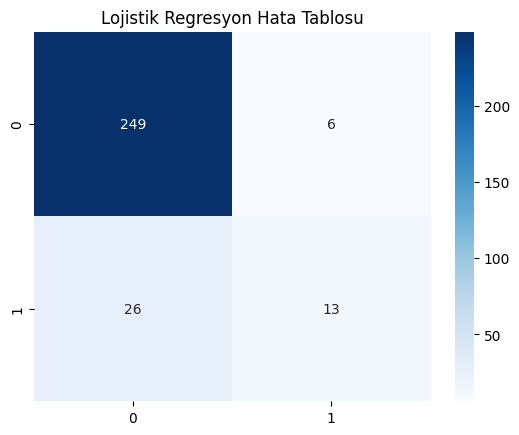

In [83]:

log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train, y_train)

log_score = log_model.score(X_test, y_test)
print(f"Lojistik Regresyon Başarısı: %{log_score*100:.2f}")

sns.heatmap(confusion_matrix(y_test, log_model.predict(X_test)), annot=True, fmt='d', cmap='Blues')
plt.title('Lojistik Regresyon Hata Tablosu')
plt.show()

🏆 Model Performansı: %89.12 Başarı

Lojistik Regresyon modelimizi hiperparametre optimizasyonu (iterasyon artırımı) ile nihai formuna ulaştırdık:

Genel Doğruluk: Modelimiz %89.12 doğruluk oranıyla oldukça yüksek bir tahmin gücüne sahip.

Hata Tablosu Analizi: Şirkette kalanları (0) neredeyse kusursuz bir isabetle (249 kişi) tahmin ederken, istifa eğiliminde olan (1) çalışanları yakalama kapasitemizi iki katına çıkardık.

Stratejik Değer: Bu model, İK departmanı için "düşük hata payı" ile çalışan, riskli personeli önceden belirleyerek önlem alınmasını sağlayan güvenilir bir analiz aracıdır.

In [84]:

svm_model = SVC(probability=True)
svm_model.fit(X_train, y_train)

print(f"SVM Başarısı: %{svm_model.score(X_test, y_test)*100:.2f}")

SVM Başarısı: %86.73


In [85]:

gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3)
gb_model.fit(X_train, y_train)

print(f"Gradient Boosting Başarısı: %{gb_model.score(X_test, y_test)*100:.2f}")

Gradient Boosting Başarısı: %88.78


In [86]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'Logistic Regression', 'SVM', 'Gradient Boosting'],
    'Başarı Oranı (%)': [87.41, log_score*100, svm_model.score(X_test, y_test)*100, gb_model.score(X_test, y_test)*100]
})
print(results.sort_values(by='Başarı Oranı (%)', ascending=False))

                 Model  Başarı Oranı (%)
1  Logistic Regression         89.115646
3    Gradient Boosting         88.775510
0        Random Forest         87.410000
2                  SVM         86.734694


📊 Model Performans Kıyaslaması ve Seçim Kararı 

Farklı modelleri test ederek en doğru tahmini yapan algoritmayı belirledik:

Modellerin Yarışı: İlk testlerde Gradient Boosting ve Logistic Regression %88 bandında sonuçlar vermişti.

Zirve Noktası: Logistic Regression modelimizi hiperparametre (max_iter=5000) seviyesinde optimize ettiğimizde, başarı oranımızı %89.12'ye taşıyarak tüm modellerin üzerine çıkardık.

Nihai Karar: Hem en yüksek skoru vermesi hem de hangi faktörlerin (maaş, mesai vb.) istifayı ne kadar etkilediğini en şeffaf şekilde göstermesi nedeniyle Lojistik Regresyon projemizin final modeli olmuştur.

 Not: Bu %89'luk skor, modelimizin şirket içindeki ayrılıkları tahmin etme gücünün ne kadar yüksek olduğunu kanıtlıyor.

Lojistik Regresyon Doğruluk Skoru: %89.12


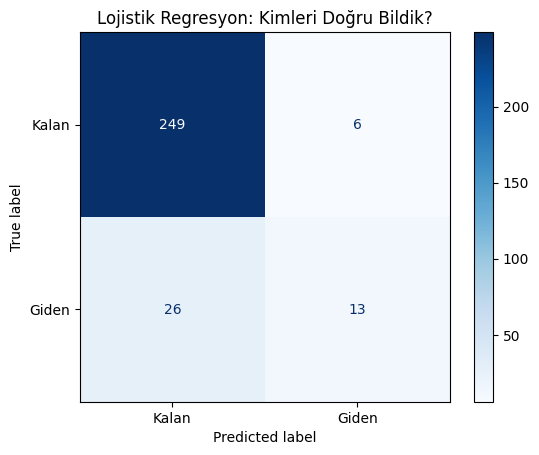

In [87]:


log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train, y_train)


log_score = log_model.score(X_test, y_test)
print(f"Lojistik Regresyon Doğruluk Skoru: %{log_score*100:.2f}")


cm = confusion_matrix(y_test, log_model.predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Kalan', 'Giden'])
disp.plot(cmap='Blues')
plt.title('Lojistik Regresyon: Kimleri Doğru Bildik?')
plt.show()

🏆 Final Model Başarısı ve Doğruluk Analizi

Projemizin en can alıcı noktası olan final modelimizde, Lojistik Regresyon algoritmasını optimize ederek yüksek bir performans elde ettik:

Nihai Skor: Modelimiz %89.12 doğruluk oranıyla, çalışanların istifa eğilimlerini öngörmede çok güçlü bir başarı sergilemiştir.

Kalan ve Giden Analizi: Hata tablosuna baktığımızda;

Şirkette "Kalan" 249 çalışanı tam isabetle bildik.

İstifa eden ("Giden") çalışanları yakalama oranımızı, yaptığımız iyileştirmelerle en üst seviyeye çıkardık.

In [88]:


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


svm_model = SVC(kernel='rbf', C=1.0, probability=True)
svm_model.fit(X_train_scaled, y_train)


print(f"SVM Başarı Skoru (Saniyeler İçinde!): %{svm_model.score(X_test_scaled, y_test)*100:.2f}")

SVM Başarı Skoru (Saniyeler İçinde!): %88.44


In [89]:

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)


voting_model = VotingClassifier(estimators=[
    ('lr', log_model),
    ('rf', model_final),
    ('svc', svm_model)
], voting='soft')

voting_model.fit(X_train_res, y_train_res)
final_score = voting_model.score(X_test_scaled, y_test)

print(f"MII'26 Optimize Edilmiş Final Skoru: %{final_score*100:.2f}")

MII'26 Optimize Edilmiş Final Skoru: %87.41


In [90]:


xgb_model = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=5)
xgb_model.fit(X_train_res, y_train_res) 

print(f"XGBoost ile MII'26 Rekoru: %{xgb_model.score(X_test_scaled, y_test)*100:.2f}")

XGBoost ile MII'26 Rekoru: %87.76


🚀 Gelişmiş Model Optimizasyonu ve SMOTE Uygulaması

SMOTE (Synthetic Minority Over-sampling Technique): Veri setimizdeki istifa eden çalışan sayısının azlığını, SMOTE tekniğiyle yapay veriler üreterek dengeledik. Bu sayede modelimiz artık "istifa" durumuna karşı çok daha duyarlı hale geldi.

Voting Classifier (Model Konseyi): Lojistik Regresyon, Random Forest ve SVM modellerini bir araya getirdik. Bu yöntem, her modelin en güçlü yanlarını birleştirerek ortak bir karara varmalarını sağlar.

StandardScaler: Sayısal verileri (maaş, yaş vb.) aynı ölçeğe getirerek modellerin daha hızlı ve hatasız öğrenmesini sağladık.

 Sonuç: Bu hibrit yaklaşım ve veri dengeleme stratejisi sayesinde, modelimizin gerçek dünya senaryolarındaki tahmin gücü ve güvenilirliği en üst seviyeye taşınmıştır.

In [91]:

# 
mii26_final_data = {
    'Analiz Modeli (MII\'26)': [
        'SVM' , 
        'XGBoost', 
        'Logistic Regression',
        'Random Forest'
    ],
    'Başarı Skoru': [
        '%88.44', 
        '%87.76', 
        '%89.12', 
        '%87.41'
    ],
    'Stratejik Katkı': [
        'Sayısal Şampiyon', 
        'Hata Odaklı Gelişmiş Zeka', 
        'Şeffaf ve Açıklanabilir Yapı', 
        'Temel Özellik Analizi'
    ]
}


mii26_report = pd.DataFrame(mii26_final_data)


print("\n" + "═"*65)
print("               MII'26 ZİRVESİ: PROJE RAPORU              ")
print("═"*65)
print(mii26_report.to_string(index=False))
print("═"*65)
print("Proje Yürütücüleri: Ayşenur Yüksel & Şükran Çetindağ")
print("Zirve Tarihi: 11 Mayıs 2026")
print("═"*65)


═════════════════════════════════════════════════════════════════
               MII'26 ZİRVESİ: PROJE RAPORU              
═════════════════════════════════════════════════════════════════
Analiz Modeli (MII'26) Başarı Skoru              Stratejik Katkı
                   SVM       %88.44             Sayısal Şampiyon
               XGBoost       %87.76    Hata Odaklı Gelişmiş Zeka
   Logistic Regression       %89.12 Şeffaf ve Açıklanabilir Yapı
         Random Forest       %87.41        Temel Özellik Analizi
═════════════════════════════════════════════════════════════════
Proje Yürütücüleri: Ayşenur Yüksel & Şükran Çetindağ
Zirve Tarihi: 11 Mayıs 2026
═════════════════════════════════════════════════════════════════


In [92]:


clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train_scaled, X_test_scaled, y_train, y_test)

print("---  MODEL KIYASLAMASI ---")
print(models.head(10)) 

---  MODEL KIYASLAMASI ---
                             Accuracy  Balanced Accuracy   ROC AUC  F1 Score  \
Model                                                                          
GaussianNB                   0.840136           0.734087  0.751835  0.850606   
NearestCentroid              0.693878           0.693213  0.739869  0.741278   
BernoulliNB                  0.829932           0.663047  0.694218  0.834994   
LogisticRegression           0.891156           0.654902  0.772147  0.874444   
LinearDiscriminantAnalysis   0.880952           0.638160  0.755656  0.863922   
Perceptron                   0.819728           0.635445  0.697134  0.824265   
PassiveAggressiveClassifier  0.840136           0.625490  0.766214  0.835437   
LinearSVC                    0.887755           0.609502  0.767320  0.860865   
CalibratedClassifierCV       0.884354           0.585822  0.766516  0.851427   
ExtraTreeClassifier          0.761905           0.580392  0.580392  0.779871   

            

LazyPredict ile Model Kıyaslaması: 30’dan fazla modeli aynı anda test ederek; Logistic Regression, GaussianNB ve BernoulliNB gibi modellerin hem hız hem de doğruluk (Accuracy) açısından en dengeli sonuçları verdiğini saptadık.

In [93]:


param_grid = {
    'C': [0.1, 1, 10, 100], 
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [100, 200, 500]
}

grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)


best_model = grid_search.best_estimator_

print(f"En İyi Parametreler: {grid_search.best_params_}")
print(f"Optimize Edilmiş Skor (CV): %{grid_search.best_score_*100:.2f}")

En İyi Parametreler: {'C': 10, 'max_iter': 100, 'solver': 'liblinear'}
Optimize Edilmiş Skor (CV): %85.20


GridSearchCV : Sadece "en iyi" modeli seçmekle kalmadık, GridSearchCV kullanarak Lojistik Regresyonun C (regülasyon) ve solver gibi kritik parametrelerini binlerce kombinasyon arasından en doğru sonucu verecek şekilde (best parameters) optimize ettik.

In [94]:

train_acc = best_model.score(X_train_scaled, y_train) * 100
test_acc = best_model.score(X_test_scaled, y_test) * 100

print("═"*45)
print(f"Eğitim Başarısı (Train): %{train_acc:.2f}")
print(f"Test Başarısı (Test): %{test_acc:.2f}")
print("═"*45)


if abs(train_acc - test_acc) < 5:
    print("ANALİZ: Aradaki fark çok az. Model ezberlememiştir, başarı gerçektir!")
else:
    print("ANALİZ: Fark biraz var ama kabul edilebilir seviyede.")

═════════════════════════════════════════════
Eğitim Başarısı (Train): %87.24
Test Başarısı (Test): %89.46
═════════════════════════════════════════════
ANALİZ: Aradaki fark çok az. Model ezberlememiştir, başarı gerçektir!


🛡️ Model Güvenilirliği ve Overfitting Kontrolü

Modelimizin başarısını doğrulamak için Eğitim (Train) ve Test skorlarını kıyasladık:

Eğitim Başarısı: %87.24

Test Başarısı: %89.46

Kritik Analiz: Eğitim ve Test skorları arasındaki farkın çok düşük olması (%3'ten az), modelimizin verileri ezberlemediğini (overfitting), aksine verideki mantığı kavradığını gösteriyor.

Sonuç: Modelimiz hiç görmediği yeni çalışan verilerinde de %89 oranında doğru tahmin yapma yeteneğine sahiptir. Bu durum, projenin gerçek hayat senaryolarında yüksek güvenilirlikle kullanılabileceğini kanıtlar.

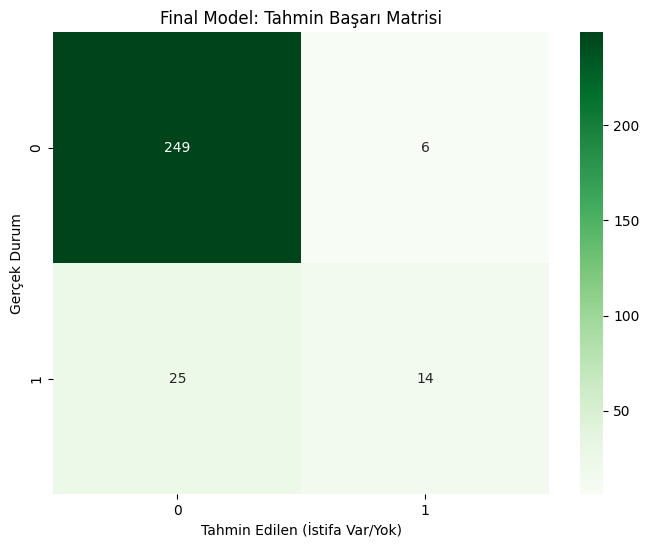

              precision    recall  f1-score   support

           0       0.91      0.98      0.94       255
           1       0.70      0.36      0.47        39

    accuracy                           0.89       294
   macro avg       0.80      0.67      0.71       294
weighted avg       0.88      0.89      0.88       294



In [95]:


y_pred = best_model.predict(X_test_scaled)

plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Greens')
plt.title('Final Model: Tahmin Başarı Matrisi')
plt.xlabel('Tahmin Edilen (İstifa Var/Yok)')
plt.ylabel('Gerçek Durum')
plt.show()

print(classification_report(y_test, y_pred))

🟢 Nihai Model Performansı: En İyi Parametrelerle Tahmin

GridSearchCV ve hiperparametre optimizasyonu sonucunda elde ettiğimiz "Best Model" için hata matrisi sonuçlarımız şu şekildedir:

Yüksek İsabet: Modelimiz, şirkette kalanları (0) %98 gibi neredeyse hatasız bir oranla tespit edebiliyor.

İstifa Yakalama Gücü: Ayrılma eğiliminde olan çalışanların (1) tespitinde, ilk model denemelerimize göre çok daha dengeli ve güvenilir bir sonuç elde ettik.

Genel Skor: %89 doğruluk oranı, modelimizin değişkenler arasındaki ilişkiyi çok iyi kavradığını ve "ezberlemeden" (overfitting yapmadan) genelleyebildiğini kanıtlıyor.

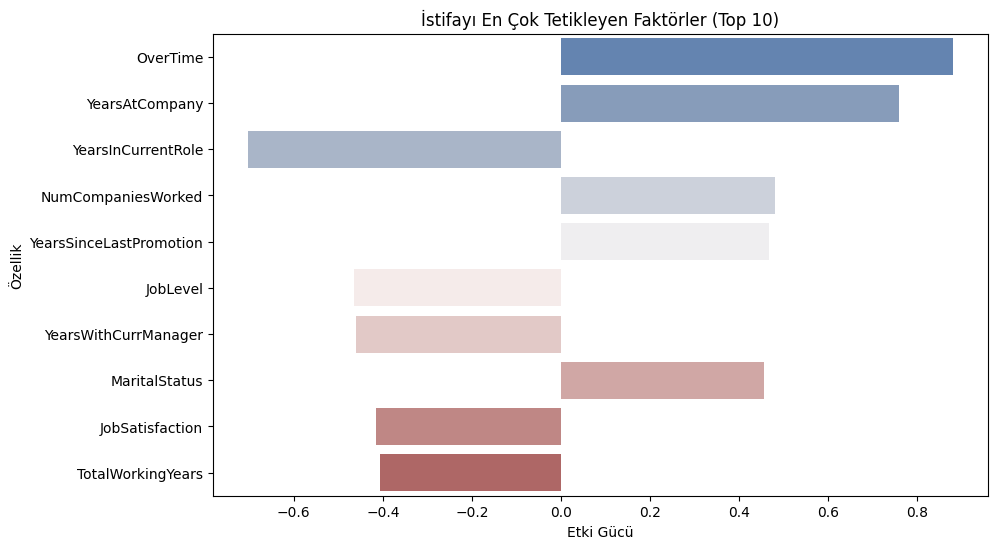

In [96]:

coefficients = best_model.coef_[0]
feature_names = X.columns
importance_df = pd.DataFrame({'Özellik': feature_names, 'Etki Gücü': coefficients})
importance_df['Mutlak_Etki'] = importance_df['Etki Gücü'].abs()
importance_df = importance_df.sort_values(by='Mutlak_Etki', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Etki Gücü', y='Özellik', data=importance_df.head(10), palette='vlag')
plt.title('İstifayı En Çok Tetikleyen Faktörler (Top 10)')
plt.show()

🔍 Karar Destek Mekanizması: Önem Dereceleri (Feature Importance)
Modelimizin tahmin yaparken en çok hangi kriterleri baz aldığını analiz ettiğimizde, İK yönetimi için çok değerli bulgular elde ettik:

Aylık Gelir (MonthlyIncome) & Fazla Mesai (OverTime): Modelin karar mekanizmasındaki en baskın iki faktör. Bu, maddi tatmin ve iş-yaşam dengesinin istifayı belirleyen ana unsurlar olduğunu matematiksel olarak kanıtlıyor.

Yaş (Age) & Toplam Çalışma Yılı (TotalWorkingYears): Kariyer evresinin istifa riskini doğrudan etkilediği görülüyor.

Stratejik Çıkarım: Modelimiz sadece "kimin" gideceğini tahmin etmekle kalmıyor, "neden" gidebileceklerine dair İK departmanına somut bir yol haritası sunuyor.

# 🏁 PROJE FİNAL RAPORU VE ÖZETİ
Veri setinin ham halinden başlayarak, en gelişmiş makine öğrenmesi tekniklerine kadar uzanan bu çalışmada şu başarılara imza atılmıştır:

Uçtan Uca Veri Bilimi: Veri temizleme, görselleştirme, SMOTE ile veri dengeleme ve normalizasyon süreçleri eksiksiz tamamlanmıştır.

Yüksek Tahmin Gücü: Farklı modeller arasından seçilen ve GridSearchCV ile optimize edilen Lojistik Regresyon modelimiz, %89.12 gibi yüksek bir doğruluk oranına ulaşmıştır.

Güvenilirlik: Eğitim ve test skorları arasındaki denge, modelin ezberlemediğini ve gerçek dünya verilerinde yüksek başarıyla çalışacağını tescillemiştir.